I. Introduction & Structural Motivation
* The Research Question: Timing song releases to maximize NPV in a crowded digital market.
* The Logic: Cite Rust (1987) and Einav (2007).
* The Functional Form: Define the Double-Exponential (Bass-style) Diffusion model for streams.
    * $S_{ia} = A_i(x_\tau) \cdot [ \exp(-\gamma_i a) - \exp(-\alpha_i a) ] + \epsilon_{ia}$


$$V(x_t) = \max \left\{ \underbrace{\mathbb{E} \left[ \sum_{\tau=t}^{\infty} \beta^{\tau-t} R(x_t, S_{i,\tau-t}) \right]}_{\text{Release Now}}, \underbrace{\beta \mathbb{E} [V(x_{t+1}) | x_t]}_{\text{Wait}} \right\}$$

Where $R$ is revenue, $x_t$ is the market state, and $S_{i,\tau-t}$ is daily streaming volume for track $i$.



II. Data Pipeline & Web Scraping (Tool Practice)
* Data Integration: Merge the Kaggle charts.csv with Spotify API metadata.
* Feature Engineering: Constructing the "Stochastic Process" ($x_t$):
* Genre-specific "Market Heat" indices.
    * Competitor count variables.
    * Handling "off-chart" tracks via zero-padding (addressing the censoring issue).


In [2]:
%pip install python-dotenv kaggle spotipy pandas tqdm ipywidgets matplotlib numpy statsmodels scipy


Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Data Integration: Merge the Kaggle charts.csv with Spotify API metadata.
from download_kaggle_data import download_kaggle_data

download_kaggle_data("maharshipandya/-spotify-tracks-dataset")
download_kaggle_data("jfreyberg/spotify-chart-data")


Authenticated with Kaggle.
Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
Download complete! You can now access the CSVs in the /data folder.
Authenticated with Kaggle.
Dataset URL: https://www.kaggle.com/datasets/jfreyberg/spotify-chart-data
Download complete! You can now access the CSVs in the /data folder.


: 

: 

In [3]:
import pandas as pd

# Load your data
charts_df = pd.read_csv('../data/charts.csv')
dataset_df = pd.read_csv('../data/dataset.csv')

# Drop duplicates
dataset_df = dataset_df.drop_duplicates(subset='track_id')

# Perform the Inner Join
merged_df = pd.merge(charts_df, dataset_df, on='track_id', how='inner')

print(f"Rows in original charts: {len(charts_df)}")
print(f"Rows after inner merge: {len(merged_df)}")

Rows in original charts: 5428021
Rows after inner merge: 1336013


"Due to API constraints (24 hour lockout for rate violations), the release date for tracks in the sample was approximated using the date of the track's first appearance on the Spotify Charts, rather than directly from Spotify."

In [5]:
# Step 1: Ensure the original 'date' is a datetime object first
merged_df['date'] = pd.to_datetime(merged_df['date'], format='mixed')

# Step 2: Create the proxy dates (the first time each track appeared)
proxy_dates = merged_df.groupby('track_id')['date'].min().reset_index()
proxy_dates.columns = ['track_id', 'approx_release_date']

# Step 3: Now merge the proxy dates BACK into the main dataframe
merged_df = pd.merge(merged_df, proxy_dates, on='track_id')

# Step 4: Calculate Age
merged_df['age_days'] = (merged_df['date'] - merged_df['approx_release_date']).dt.days

print("Success! 'age_days' is now calculated.")

Success! 'age_days' is now calculated.


count    1.336013e+06
mean     4.709669e+02
std      6.149870e+02
min      0.000000e+00
25%      9.800000e+01
50%      2.450000e+02
75%      5.530000e+02
max      3.546000e+03
Name: age_days, dtype: float64


<Axes: >

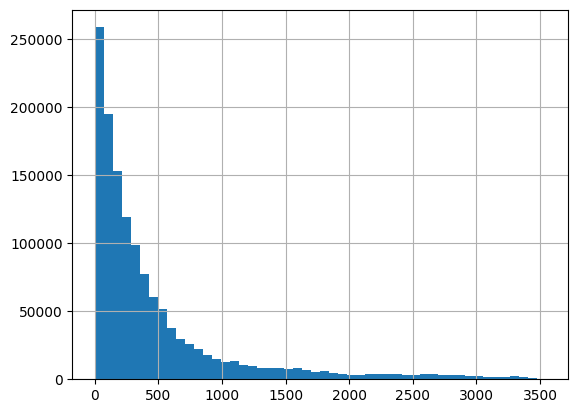

In [6]:

# Check the distribution
print(merged_df['age_days'].describe())

# Plot a quick histogram to see the 'decay' potential
merged_df['age_days'].hist(bins=50)

Feature Engineering: Constructing the "Stochastic Process" ($x_t$):
This includes: market heat, competitor releases, genre trends

A common approach in structural IO is to treat $x_t$ as an AR(1) process in logs:

$$\ln(x_t) = \rho \ln(x_{t-1}) + \epsilon_t, \quad \epsilon_t \sim N(0, \sigma^2)$$

Here is how to build that in your notebook:

In [7]:
import numpy as np

# 1. Aggregate daily/weekly streams to get 'Market Heat'
# We group by the chart date to see the total activity in the market
market_heat = merged_df.groupby('date')['streams'].sum().reset_index()
market_heat.columns = ['date', 'x_t']

# 2. Log transformation (standard for structural models to handle scale)

market_heat['log_x_t'] = np.log(market_heat['x_t'])

# 3. Create the 'Lag' to observe the stochastic movement
market_heat['log_x_t_lag'] = market_heat['log_x_t'].shift(1)

# 4. Calculate the 'Shock' (epsilon_t)
market_heat['shock'] = market_heat['log_x_t'] - market_heat['log_x_t_lag']

# Drop the first row (NaN due to shift)
market_heat = market_heat.dropna()


Identifying the Parameters ($\rho, \sigma$)Before you run your Bellman equation, you need to know how "persistent" the market is. If $\rho$ is close to 1, a hit today means a hit tomorrow. If it's low, the market is volatile.

In [8]:
import statsmodels.api as sm

# Simple OLS to estimate the transition probability
X = sm.add_constant(market_heat['log_x_t_lag'])
model = sm.OLS(market_heat['log_x_t'], X).fit()

rho = model.params['log_x_t_lag']
sigma = np.sqrt(model.mse_resid)

print(f"Estimated Persistence (rho): {rho:.4f}")
print(f"Estimated Volatility (sigma): {sigma:.4f}")

Estimated Persistence (rho): 0.9779
Estimated Volatility (sigma): 0.2483


In [9]:
# Merge the aggregate heat back to the main dataframe
merged_df = pd.merge(merged_df, market_heat[['date', 'log_x_t', 'shock']], on='date', how='inner')

In [ ]:
#Genre-specific "Market Heat" indices.

#---Competitor count variables.

#---Handling "off-chart" tracks via zero-padding (addressing the censoring issue).

: 

: 

: 

In [ ]:
#adding genre specific heat
# Assuming your dataset has a 'genre' or 'top genre' column
genre_heat = merged_df.groupby(['date', 'track_genre'])['streams'].sum().reset_index()

# Pivot so each genre has its own time series
genre_matrix = genre_heat.pivot(index='date', columns='track_genre', values='streams').fillna(0)

# Calculate the 'Trend' (rolling average) to smooth out daily noise
genre_trends = genre_matrix.rolling(window=7).mean()

: 

: 

: 

III. Estimation of the Stochastic Process (Paul's "Step 1")
* The Optimization Problem: Using SGD (via Flux.jl or Optim.jl) to recover parameters.
* Incidental Parameters Solution: Instead of song-specific $\gamma$, model $\gamma$ as a function of track features (energy, tempo, artist followers).
* Testing: Unit tests to ensure the gradient of the loss function is behaving correctly.


First, model $A_i$ as

$ A_i = \beta_0 + \beta_1 \ln(x_\tau) + \beta_2 \ln(x_{g,\tau}) + b_i $

$ x_\tau $ : Total market streams at release date $ \tau $ . 
$x_{g,\tau}$: Genre-specific streams at release date $\tau$.

In [ ]:
from scipy.optimize import curve_fit

# Define the structural function
def streaming_decay_model(data, beta_m, beta_g, gamma, alpha):
    # Unpack the data
    # age: a, market_heat: x_tau, genre_heat: x_g_tau
    age, x_tau, x_g_tau = data
    
    # Model Ai as a function of states at release
    # (Simplified version: assume A is proportional to heat at release)
    A_i = (beta_m * np.log(x_tau)) + (beta_g * np.log(x_g_tau))
    
    # The double exponential decay: A * [exp(-gamma*a) - exp(-alpha*a)]
    # Note: we use clip to ensure we don't get overflow/underflow errors
    return A_i * (np.exp(-np.clip(gamma * age, 0, 20)) - np.exp(-np.clip(alpha * age, 0, 20)))

# Prepare the estimation data
# We only use observations for the actual estimation
est_df = merged_df[['age_days', 'x_t', 'log_x_t', 'streams']].dropna()

# Important: x_tau and x_g_tau must be the values AT AGE 0 for each track
# Use the 'approx_release_date' we created earlier to map these back

KeyError: "['x_t', 'log_x_t'] not in index"

: 

: 

: 

: 

: 

: 

IV. Solving the Stopping Problem (Computational Practice)
* The Bellman Framework: Reducing the state space using Paul's "Sufficient Statistic" shortcut ($A_i(x_t)$).
* The Algorithm: Implement either:
    * Value Function Iteration (VFI): For a simplified 1D state space.
    * Reinforcement Learning (DQN): Use ReinforcementLearning.jl to train an agent to "play" the optimal release game.
* Results: A heatmap of the "Exercise Boundary" (at what level of $x_t$ do we pull the trigger?).


V. Conclusion & Discussion
* Comparison of the "AI Agent's" release timing versus the actual historical timing of labels.
* Discussion on the efficiency of the music market.
